### SMOTE - Synthetic Minority Oversampling Technique

In [12]:
from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
x,y =make_classification(n_samples=1000, n_redundant=0,n_features=2,n_clusters_per_class=1, weights=[0.90], random_state=12)

In [5]:
df1 = pd.DataFrame(x,columns=['F1','F2'])
df2 = pd.DataFrame(y,columns=['Target'])
finalDF =pd.concat([df1,df2],axis=1)

In [11]:
finalDF['Target'].value_counts()

Target
0    900
1    100
Name: count, dtype: int64

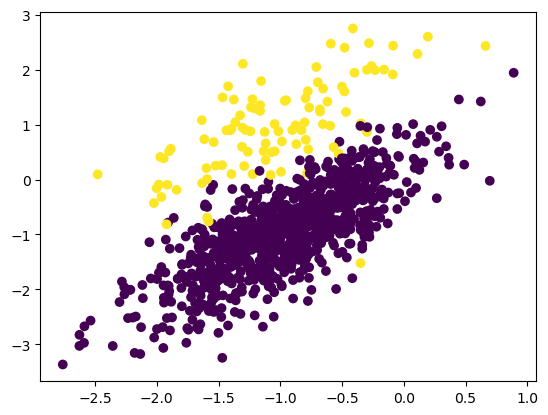

In [13]:
plt.scatter(finalDF['F1'],finalDF['F2'],c=finalDF['Target'])

In [14]:
!pip install imblearn

In [15]:
from imblearn.over_sampling import SMOTE

In [17]:
oversample = SMOTE()
x,y=oversample.fit_resample(finalDF[['F1', 'F2']], finalDF['Target'])

In [20]:
x.shape

(1800, 2)

In [21]:
y.shape

(1800,)

In [22]:
df1 = pd.DataFrame(x,columns=['F1', 'F2'])
df2 = pd.DataFrame(y,columns=['Target'])

In [24]:
Dataset = pd.concat([df1,df2],axis=1)

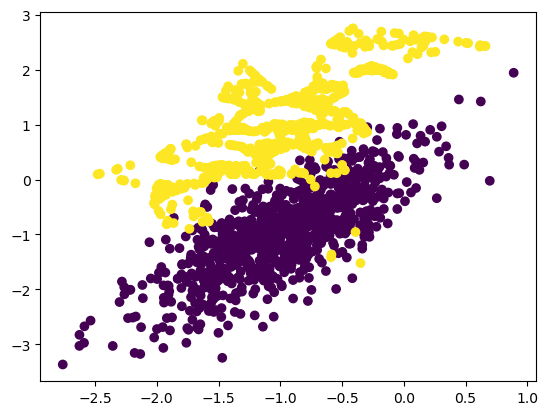

In [26]:
plt.scatter(Dataset['F1'],Dataset['F2'],c=Dataset['Target'])

In [27]:
Dataset['Target'].value_counts()

Target
0    900
1    900
Name: count, dtype: int64

## Handling Outliers

In [28]:
import numpy as np

In [31]:
lst_marks = [45,32,56,34,78,89,97,43,67,85,85,84,83,56,59,78]
mini,Q1,median,Q3,maxi=np.quantile(lst_marks,[0,0.25,0.50,0.75,1])

In [33]:
print(mini,Q1,median,Q3,maxi)

32.0 53.25 72.5 84.25 97.0


In [34]:
IQR=Q3-Q1
IQR

np.float64(31.0)

In [36]:
lower_fence = Q1-1.5*(IQR)

In [37]:
higher_fence = Q3+1.5*(IQR)

In [39]:
print(lower_fence)
print(higher_fence)

6.75
130.75


In [40]:
import seaborn as sns

<Axes: >

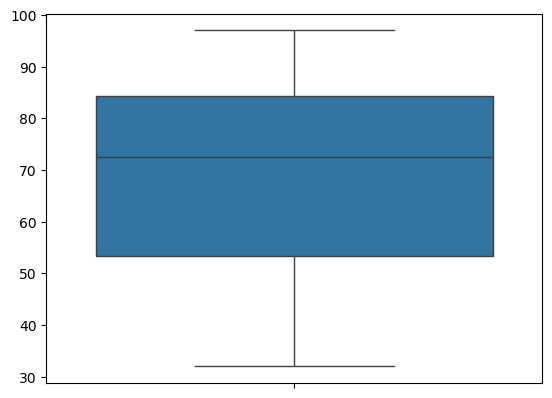

In [41]:
sns.boxplot(lst_marks)

In [56]:
lst_marks2 = [-100,-121,-80,45,32,56,34,78,89,97,43,67,85,85,84,83,56,59,78,200,1000]

<Axes: >

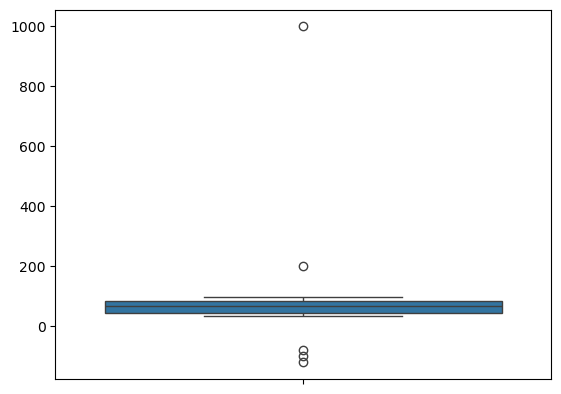

In [57]:
sns.boxplot(lst_marks2)